In [ ]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. Carregar o dataset clássico da UCI
raw_data = load_breast_cancer()
X = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
y = raw_data.target

# 2. Dividir: 2/3 treino, 1/3 teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42
)

# 3. Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=raw_data.feature_names)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=raw_data.feature_names)

print(f"Dataset carregado! Total de atributos: {X.shape[1]}")
print(f"Classes: {raw_data.target_names} (0 = Maligno, 1 = Benigno)")
print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Dataset carregado! Total de atributos: 30
Classes: ['malignant' 'benign'] (0 = Maligno, 1 = Benigno)
Treino: 379 amostras | Teste: 190 amostras


In [36]:
# ============================================================
# CÉLULA 2 — Treinar MLP (idêntico ao Exemplo 2)
# ============================================================
from sklearn.neural_network import MLPClassifier

# 2 camadas ocultas de 15 neurônios, 1000 iterações, mesmo seed
mlp_model = MLPClassifier(
    hidden_layer_sizes=(15, 15),
    max_iter=1000,
    random_state=42
)
mlp_model.fit(X_train_scaled, y_train)

acuracia = mlp_model.score(X_test_scaled, y_test)
print(f"Acurácia da Rede Neural (MLP) no teste: {acuracia:.4f}")
print("\n--- Tentando 'olhar' dentro da Caixa-Preta (Pesos da Primeira Camada) ---")

# Mostrar apenas uma fração dos milhares de pesos gerados
pesos_exemplo = mlp_model.coefs_[0][:3, :5] 
print(pesos_exemplo)

Acurácia da Rede Neural (MLP) no teste: 0.9842

--- Tentando 'olhar' dentro da Caixa-Preta (Pesos da Primeira Camada) ---
[[ 0.03826325  0.30317297  0.17054346  0.21022992 -0.3458957 ]
 [ 0.08427768 -0.32942908  0.13691608  0.20205875 -0.32873359]
 [ 0.20309663 -0.26872847 -0.30427709  0.46202036  0.24570926]]


In [37]:
# ============================================================
# CÉLULA 3 — Selecionar paciente e mostrar contexto
# ============================================================
PACIENTE_IDX = 0  # Altere para explorar outros pacientes

paciente_dados = X_test_scaled[PACIENTE_IDX]
classe_real    = raw_data.target_names[y_test[PACIENTE_IDX]]
predicao       = raw_data.target_names[mlp_model.predict([paciente_dados])[0]]
prob           = mlp_model.predict_proba([paciente_dados])[0]

print("=" * 55)
print(f"  Paciente selecionado  : Índice {PACIENTE_IDX}")
print(f"  Diagnóstico Real      : {classe_real}")
print(f"  Predição do Modelo    : {predicao}")
print(f"  P(Maligno) = {prob[0]:.4f}  |  P(Benigno) = {prob[1]:.4f}")
print("=" * 55)
print()
print("LIME e SHAP vão explicar *por que* o modelo chegou")
print("a essa predição, mostrando quais features contribuíram")
print("e em qual direção (Maligno ou Benigno).")

  Paciente selecionado  : Índice 0
  Diagnóstico Real      : benign
  Predição do Modelo    : benign
  P(Maligno) = 0.0403  |  P(Benigno) = 0.9597

LIME e SHAP vão explicar *por que* o modelo chegou
a essa predição, mostrando quais features contribuíram
e em qual direção (Maligno ou Benigno).


Gerando explicação LIME...


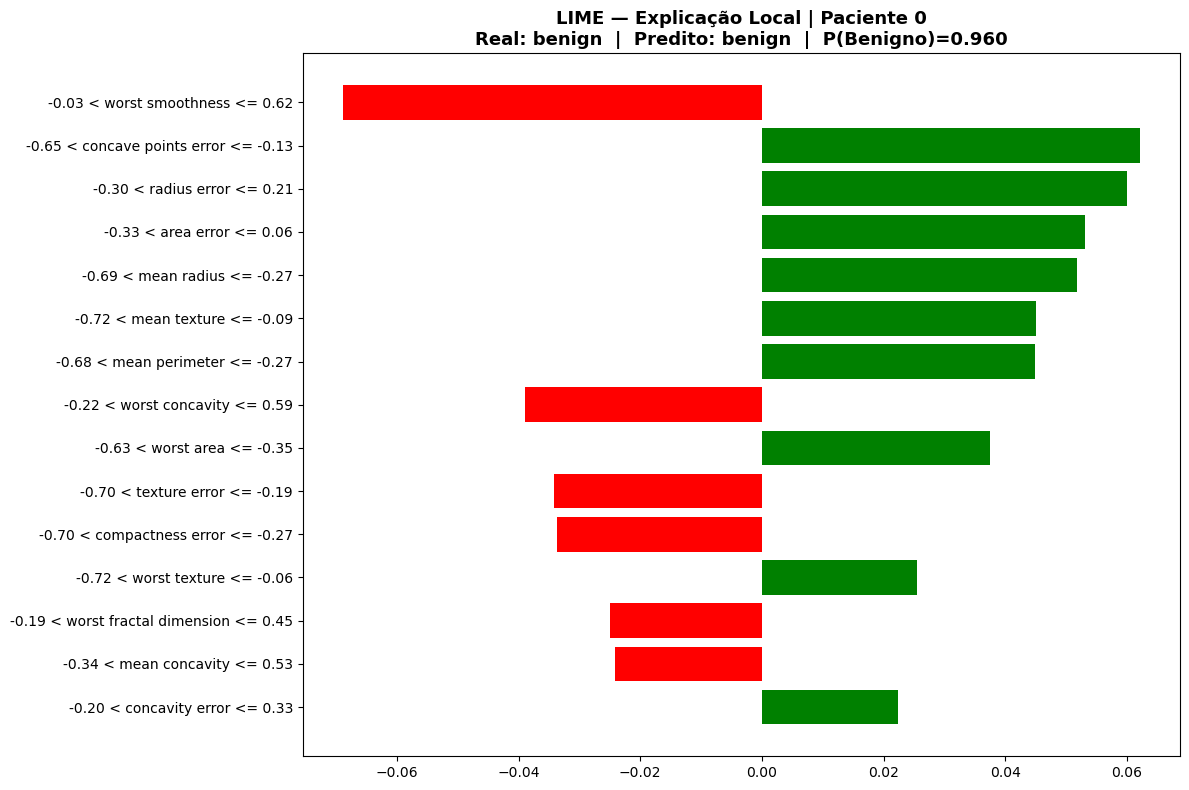

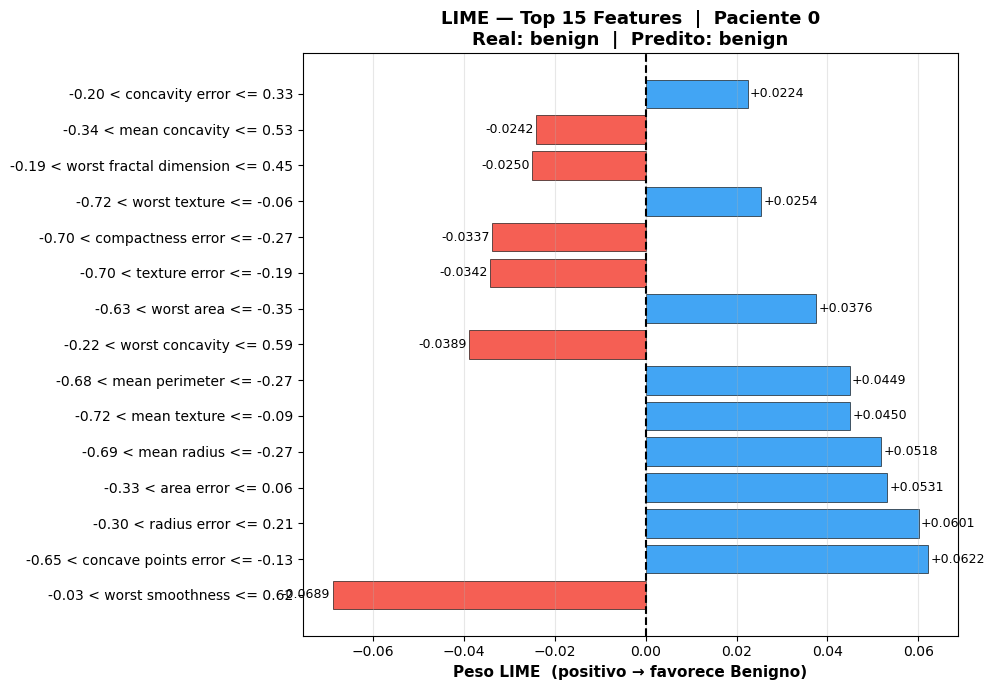

✓ LIME concluído!

Interpretação:
  Azul     → feature empurra a predição para BENIGNO
  Vermelho → feature empurra a predição para MALIGNO


In [38]:
# ============================================================
# CÉLULA 4 — LIME: Explicação Local
# ============================================================
from lime import lime_tabular

print("Gerando explicação LIME...")

explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=list(raw_data.feature_names),
    class_names=list(raw_data.target_names),
    mode='classification',
    random_state=42
)

exp_lime = explainer_lime.explain_instance(
    data_row=paciente_dados,
    predict_fn=mlp_model.predict_proba,
    num_features=15,   # top 15 features
    num_samples=2000   # mais amostras = mais estável
)

# ── Gráfico nativo do LIME ─────────────────────────────────
fig_lime = exp_lime.as_pyplot_figure()
fig_lime.set_size_inches(12, 8)
fig_lime.axes[0].set_title(
    f"LIME — Explicação Local | Paciente {PACIENTE_IDX}\n"
    f"Real: {classe_real}  |  Predito: {predicao}  |  P(Benigno)={prob[1]:.3f}",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("lime_explicacao.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico customizado (mais limpo para apresentação) ──────
exp_list = exp_lime.as_list()
feat_names_lime = [item[0] for item in exp_list]
weights_lime    = [item[1] for item in exp_list]

# Ordenar por valor absoluto decrescente
sorted_pairs = sorted(zip(feat_names_lime, weights_lime),
                      key=lambda x: abs(x[1]), reverse=True)
feat_sorted, w_sorted = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2196F3' if w > 0 else '#F44336' for w in w_sorted]

bars = ax.barh(range(len(feat_sorted)), w_sorted,
               color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(feat_sorted)))
ax.set_yticklabels(feat_sorted, fontsize=10)
ax.set_xlabel('Peso LIME  (positivo → favorece Benigno)',
              fontsize=11, fontweight='bold')
ax.set_title(
    f"LIME — Top 15 Features  |  Paciente {PACIENTE_IDX}\n"
    f"Real: {classe_real}  |  Predito: {predicao}",
    fontsize=13, fontweight='bold'
)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, w_sorted):
    ha     = 'left' if val >= 0 else 'right'
    offset = 0.0005  if val >= 0 else -0.0005
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig("lime_barras.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ LIME concluído!")
print("\nInterpretação:")
print("  Azul     → feature empurra a predição para BENIGNO")
print("  Vermelho → feature empurra a predição para MALIGNO")

Gerando SHAP values locais (aguarde alguns instantes)...


100%|██████████| 1/1 [00:00<00:00, 84.07it/s]


Estrutura retornada: <class 'numpy.ndarray'>
  shape=(1, 30, 2)
vals_benigno shape: (30,)  (deve ser (30,))
Expected value (Benigno): 0.6230


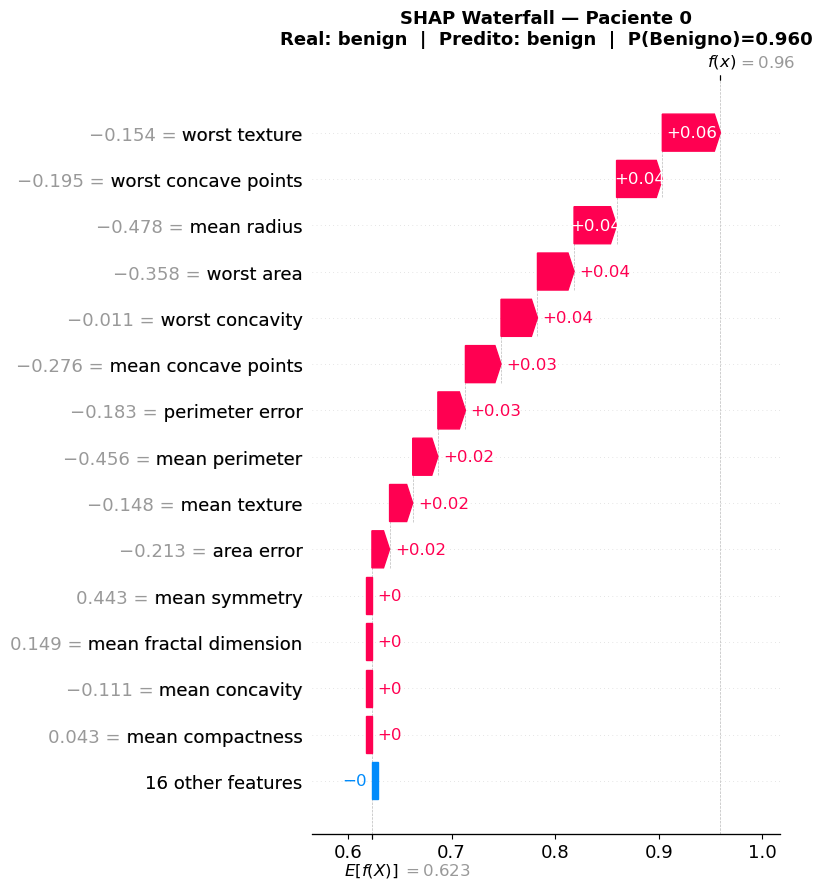

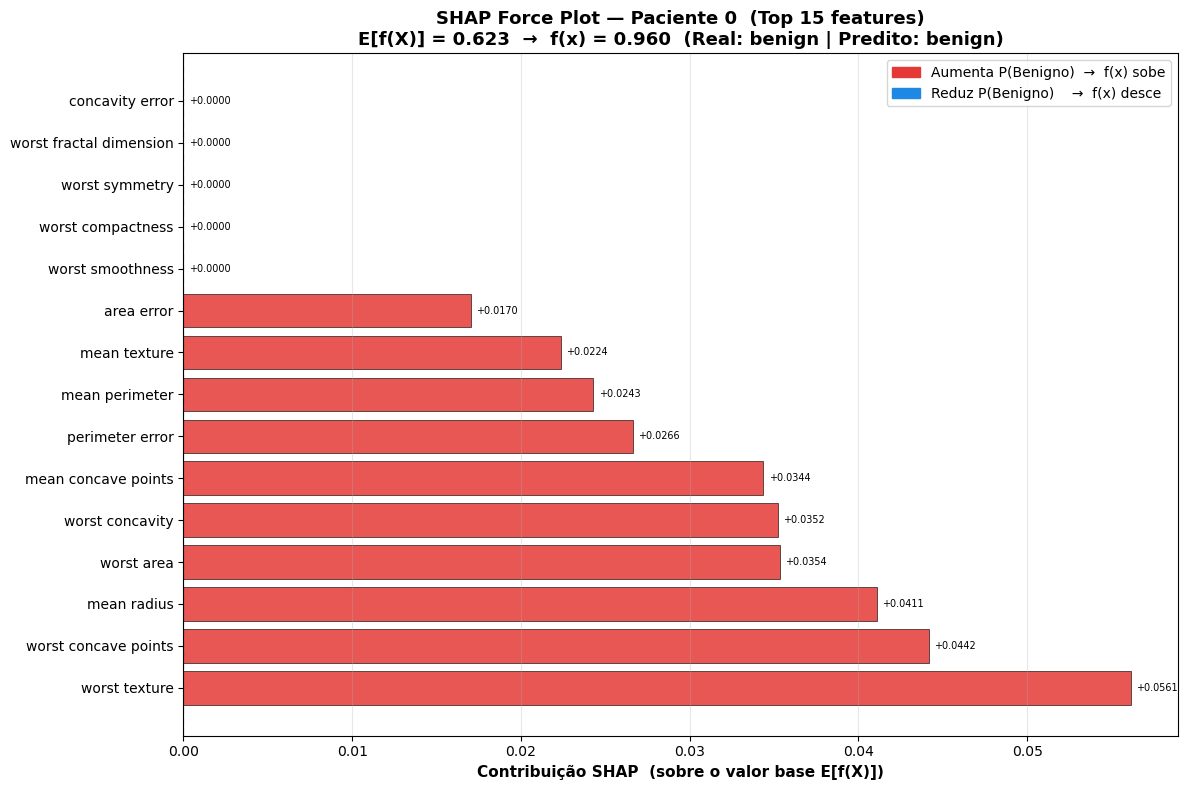


✓ SHAP local concluído!

  Valor base  E[f(x)] : 0.6230  (predição média do modelo)
  Valor final   f(x)  : 0.9597  (predição para este paciente)
  Diferença           : +0.3367
  Vermelho → feature empurra P(Benigno) para CIMA
  Azul     → feature empurra P(Benigno) para BAIXO


In [42]:
# ============================================================
# CÉLULA 5 — SHAP: Explicação Local (Waterfall + Force Plot)
# ============================================================
import shap
shap.initjs()

print("Gerando SHAP values locais (aguarde alguns instantes)...")

# Resumir dados de treino com k-means para acelerar o KernelExplainer
background = shap.kmeans(X_train_scaled, 30)

explainer_shap = shap.KernelExplainer(
    mlp_model.predict_proba,
    background,
    link='identity'
)

# SHAP values para UM paciente
shap_vals_single = explainer_shap.shap_values(
    X_test_scaled[PACIENTE_IDX:PACIENTE_IDX + 1],
    nsamples=500
)

# ── Diagnóstico da estrutura retornada ────────────────────────────
print(f"\nEstrutura retornada: {type(shap_vals_single)}")
if isinstance(shap_vals_single, list):
    print(f"  len={len(shap_vals_single)}, "
          f"shapes={[np.array(v).shape for v in shap_vals_single]}")
else:
    print(f"  shape={np.array(shap_vals_single).shape}")

# ── Extrair SHAP values da classe Benigno (índice 1) ─────────────
#
# O KernelExplainer pode retornar formatos diferentes conforme
# a versão do SHAP:
#
#   Formato A (lista)  : list[2] → cada item shape (1, 30)
#                        → vals = shap_vals_single[1][0]
#
#   Formato B (ndarray): shape (1, 30, 2)  = (amostras, features, classes)
#                        → vals = shap_vals_single[0, :, 1]
#
#   Formato C (ndarray): shape (1, 30)     = somente 1 saída
#                        → vals = shap_vals_single[0]
#
if isinstance(shap_vals_single, list):
    if len(shap_vals_single) > 1:
        vals_benigno = shap_vals_single[1][0]
    else:
        vals_benigno = shap_vals_single[0][0]
elif isinstance(shap_vals_single, np.ndarray):
    if shap_vals_single.ndim == 3:
        # Formato B — (amostras, features, classes)
        vals_benigno = shap_vals_single[0, :, 1]
    else:
        vals_benigno = shap_vals_single[0]
else:
    raise ValueError(f"Formato não reconhecido: {type(shap_vals_single)}")

vals_benigno = np.array(vals_benigno)
print(f"vals_benigno shape: {vals_benigno.shape}  (deve ser (30,))")

# ── Extrair expected_value da classe Benigno ──────────────────────
ev = explainer_shap.expected_value
if hasattr(ev, '__len__'):
    base_val = float(ev[1]) if len(ev) > 1 else float(ev[0])
else:
    base_val = float(ev)

print(f"Expected value (Benigno): {base_val:.4f}")

feature_names_list = list(raw_data.feature_names)

# ── Waterfall Plot ────────────────────────────────────────────────
explanation = shap.Explanation(
    values=vals_benigno,
    base_values=base_val,
    data=X_test_scaled[PACIENTE_IDX],
    feature_names=feature_names_list
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(
    f"SHAP Waterfall — Paciente {PACIENTE_IDX}\n"
    f"Real: {classe_real}  |  Predito: {predicao}  |  P(Benigno)={prob[1]:.3f}",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Force Plot customizado (legível) ─────────────────────────────
# O force_plot nativo do SHAP (matplotlib=True) comprime todos os
# nomes numa linha quando há muitas features — bug conhecido.
# Substituímos por barras horizontais que mostram a mesma informação:
# partindo de E[f(X)], cada feature empurra a predição para cima
# (vermelho) ou para baixo (azul).

# Top 15 features por valor absoluto
idx_sorted  = np.argsort(np.abs(vals_benigno))[::-1][:15]
feat_fp     = np.array(feature_names_list)[idx_sorted]
vals_fp     = vals_benigno[idx_sorted]
final_pred  = base_val + vals_benigno.sum()

fig, ax = plt.subplots(figsize=(12, 8))

cores = ['#E53935' if v > 0 else '#1E88E5' for v in vals_fp]
bars  = ax.barh(
    range(len(feat_fp)), vals_fp,
    color=cores, alpha=0.85,
    edgecolor='black', linewidth=0.5
)

ax.set_yticks(range(len(feat_fp)))
ax.set_yticklabels(feat_fp, fontsize=10)
ax.set_xlabel('Contribuição SHAP  (sobre o valor base E[f(X)])',
              fontsize=11, fontweight='bold')
ax.set_title(
    f'SHAP Force Plot — Paciente {PACIENTE_IDX}  (Top 15 features)\n'
    f'E[f(X)] = {base_val:.3f}  →  f(x) = {final_pred:.3f}  '
    f'(Real: {classe_real} | Predito: {predicao})',
    fontsize=13, fontweight='bold'
)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, vals_fp):
    ha     = 'left'  if val >= 0 else 'right'
    offset = 0.0003  if val >= 0 else -0.0003
    ax.text(val + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=7) #9

from matplotlib.patches import Patch
legenda = [
    Patch(color='#E53935', label=f'Aumenta P(Benigno)  →  f(x) sobe'),
    Patch(color='#1E88E5', label=f'Reduz P(Benigno)    →  f(x) desce'),
]
ax.legend(handles=legenda, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig("shap_force_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ SHAP local concluído!")
print(f"\n  Valor base  E[f(x)] : {base_val:.4f}  (predição média do modelo)")
print(f"  Valor final   f(x)  : {final_pred:.4f}  (predição para este paciente)")
print(f"  Diferença           : {final_pred - base_val:+.4f}")
print("  Vermelho → feature empurra P(Benigno) para CIMA")
print("  Azul     → feature empurra P(Benigno) para BAIXO")


Calculando SHAP values globais (subconjunto do teste)...
Isso pode levar alguns minutos...



100%|██████████| 60/60 [00:00<00:00, 120.70it/s]


Estrutura retornada (global): <class 'numpy.ndarray'>
  shape=(60, 30, 2)
shap_vals_para_plot shape: (60, 30)  (deve ser (60, 30))


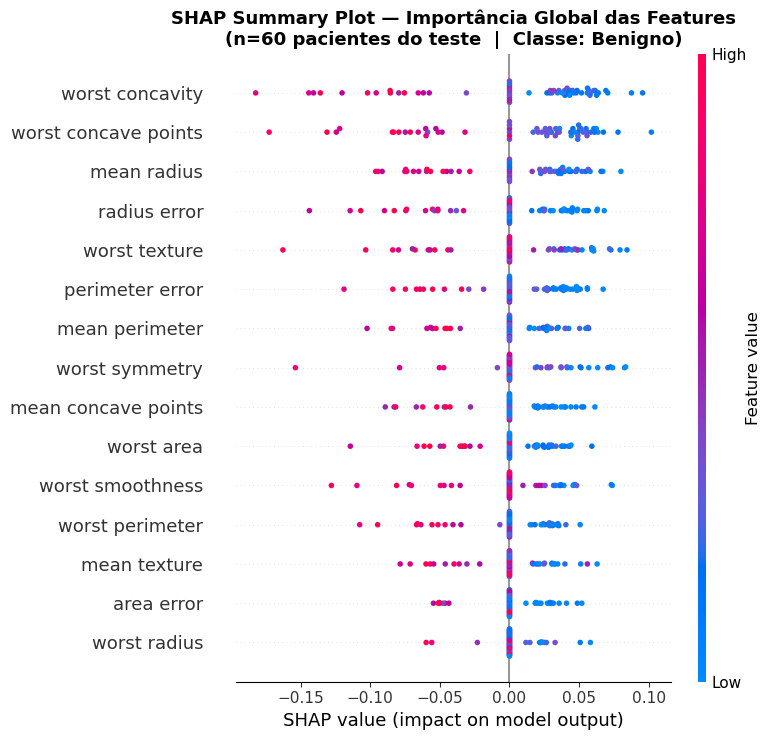

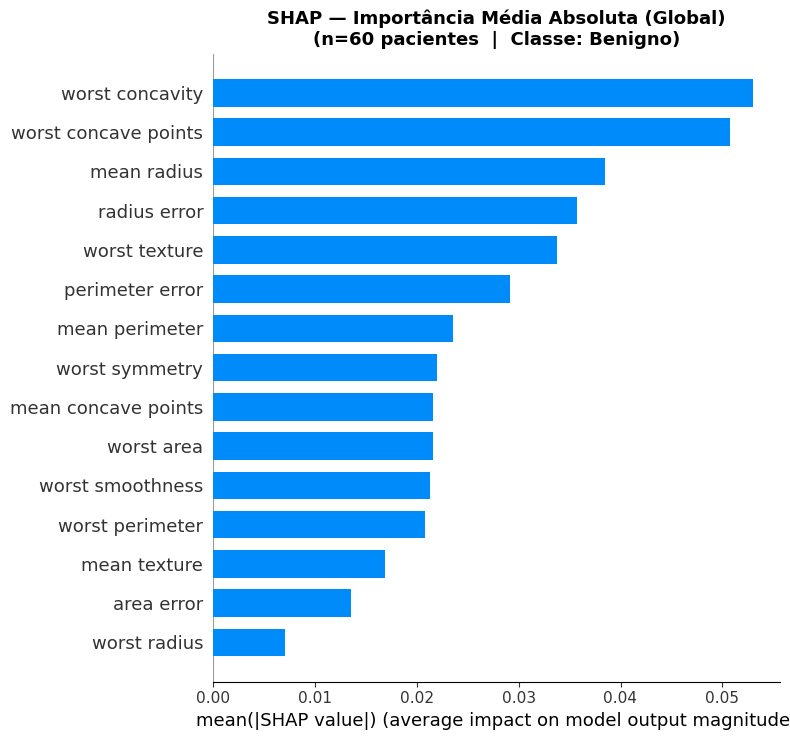

✓ SHAP global concluído!

Interpretação do Summary Plot (pontos):
  Cada LINHA  = uma feature
  Cada PONTO  = um paciente
  Cor VERMELHA = valor alto da feature  |  Azul = valor baixo
  Posição no eixo X = impacto na predição (positivo → Benigno)


In [43]:
# ============================================================
# CÉLULA 6 — SHAP: Explicação Global (Summary Plot)
# Grande diferencial em relação ao LIME!
# ============================================================
print("Calculando SHAP values globais (subconjunto do teste)...")
print("Isso pode levar alguns minutos...\n")

N_GLOBAL = min(60, len(X_test_scaled))   # ajuste conforme sua máquina
X_test_global = X_test_scaled[:N_GLOBAL]

shap_vals_global = explainer_shap.shap_values(
    X_test_global,
    nsamples=200   # menos amostras/ponto = mais rápido
)

# ── Diagnóstico da estrutura global ──────────────────────────────
print(f"Estrutura retornada (global): {type(shap_vals_global)}")
if isinstance(shap_vals_global, list):
    print(f"  len={len(shap_vals_global)}, "
          f"shapes={[np.array(v).shape for v in shap_vals_global]}")
else:
    print(f"  shape={np.array(shap_vals_global).shape}")

# ── Extrair SHAP values globais da classe Benigno ─────────────────
#
# Mesmo mapeamento de formatos da Célula 5, mas agora com N amostras:
#
#   Formato A (lista)  : list[2] → cada item shape (N, 30)
#                        → shap_vals_global[1]          shape (N, 30)
#
#   Formato B (ndarray): shape (N, 30, 2)
#                        → shap_vals_global[:, :, 1]    shape (N, 30)
#
#   Formato C (ndarray): shape (N, 30)
#                        → shap_vals_global              shape (N, 30)
#
if isinstance(shap_vals_global, list):
    if len(shap_vals_global) > 1:
        shap_vals_para_plot = np.array(shap_vals_global[1])
    else:
        shap_vals_para_plot = np.array(shap_vals_global[0])
elif isinstance(shap_vals_global, np.ndarray):
    if shap_vals_global.ndim == 3:
        # Formato B — (N, features, classes)
        shap_vals_para_plot = shap_vals_global[:, :, 1]
    else:
        # Formato C — (N, features)
        shap_vals_para_plot = shap_vals_global
else:
    raise ValueError(f"Formato não reconhecido: {type(shap_vals_global)}")

print(f"shap_vals_para_plot shape: {shap_vals_para_plot.shape}  "
      f"(deve ser ({N_GLOBAL}, 30))")

# ── Summary Plot — pontos (valor da feature + impacto) ────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals_para_plot,
    X_test_global,
    feature_names=feature_names_list,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title(
    "SHAP Summary Plot — Importância Global das Features\n"
    f"(n={N_GLOBAL} pacientes do teste  |  Classe: Benigno)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("shap_summary_dot.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Plot — barras (|SHAP| médio) ─────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_para_plot,
    X_test_global,
    feature_names=feature_names_list,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title(
    "SHAP — Importância Média Absoluta (Global)\n"
    f"(n={N_GLOBAL} pacientes  |  Classe: Benigno)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ SHAP global concluído!")
print("\nInterpretação do Summary Plot (pontos):")
print("  Cada LINHA  = uma feature")
print("  Cada PONTO  = um paciente")
print("  Cor VERMELHA = valor alto da feature  |  Azul = valor baixo")
print("  Posição no eixo X = impacto na predição (positivo → Benigno)")

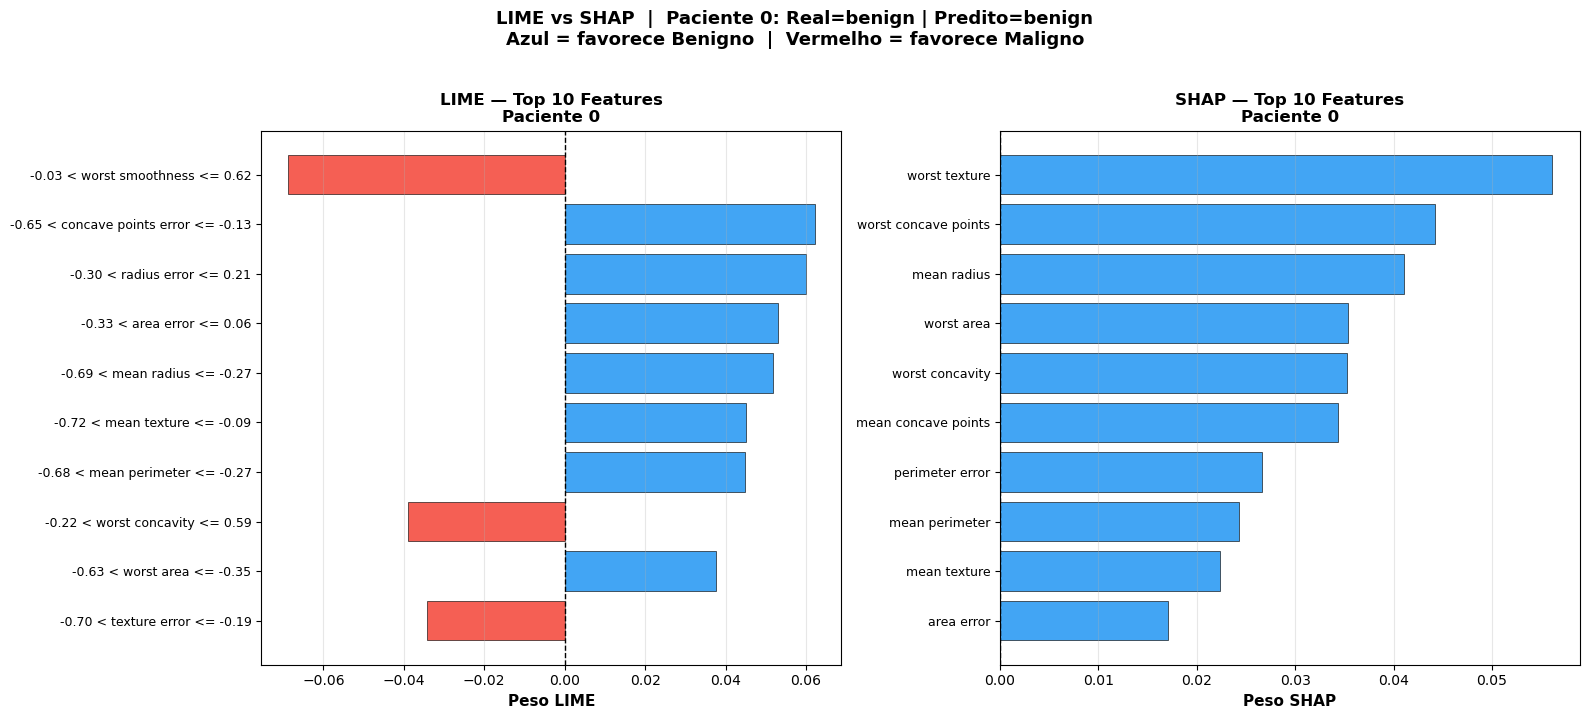


  RESUMO — Paciente 0
  Real: benign  |  Predito: benign  |  P(Benigno)=0.960

Top 5 features por LIME:
  -0.03 < worst smoothness <= 0.62            -0.0689  → Maligno
  -0.65 < concave points error <= -0.13       +0.0622  → Benigno
  -0.30 < radius error <= 0.21                +0.0601  → Benigno
  -0.33 < area error <= 0.06                  +0.0531  → Benigno
  -0.69 < mean radius <= -0.27                +0.0518  → Benigno

Top 5 features por SHAP (classe Benigno):
  worst texture                               +0.0561  → Benigno
  worst concave points                        +0.0442  → Benigno
  mean radius                                 +0.0411  → Benigno
  worst area                                  +0.0354  → Benigno
  worst concavity                             +0.0352  → Benigno


In [ ]:
# ============================================================
# CÉLULA 7 — Comparação LIME vs SHAP
# ============================================================
import pandas as pd

# ── Top features por LIME ─────────────────────────────────────────
lime_df = (
    pd.DataFrame(exp_lime.as_list(), columns=['feature', 'lime_weight'])
        .assign(lime_abs=lambda d: d['lime_weight'].abs())
        .sort_values('lime_abs', ascending=False)
        .head(10)
)

# ── Top features por SHAP ─────────────────────────────────────────
shap_df = (
    pd.DataFrame({'feature': feature_names_list, 'shap_value': vals_benigno})
        .assign(shap_abs=lambda d: d['shap_value'].abs())
        .sort_values('shap_abs', ascending=False)
        .head(10)
)

# ── Gráfico lado a lado ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, df, col, label in [
    (axes[0], lime_df, 'lime_weight', 'LIME'),
    (axes[1], shap_df, 'shap_value',  'SHAP')
]:
    vals  = df[col].iloc[::-1].values
    feats = df['feature'].iloc[::-1].values
    colors = ['#2196F3' if v > 0 else '#F44336' for v in vals]

    ax.barh(range(len(vals)), vals, color=colors,
            alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(feats, fontsize=9)
    ax.set_xlabel(f'Peso {label}', fontsize=11, fontweight='bold')
    ax.set_title(
        f'{label} — Top 10 Features\nPaciente {PACIENTE_IDX}',
        fontsize=12, fontweight='bold'
    )
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(
    f"LIME vs SHAP  |  Paciente {PACIENTE_IDX}: "
    f"Real={classe_real} | Predito={predicao}\n"
    "Azul = favorece Benigno  |  Vermelho = favorece Maligno",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("comparacao_lime_shap.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Tabela resumo no console ──────────────────────────────────────
print(f"\n{'='*55}")
print(f"  RESUMO — Paciente {PACIENTE_IDX}")
print(f"  Real: {classe_real}  |  Predito: {predicao}  |  P(Benigno)={prob[1]:.3f}")
print(f"{'='*55}")

print("\nTop 5 features por LIME:")
for _, r in lime_df.head(5).iterrows():
    direcao = "→ Benigno" if r['lime_weight'] > 0 else "→ Maligno"
    print(f"  {r['feature']:42s}  {r['lime_weight']:+.4f}  {direcao}")

print("\nTop 5 features por SHAP (classe Benigno):")
for _, r in shap_df.head(5).iterrows():
    direcao = "→ Benigno" if r['shap_value'] > 0 else "→ Maligno"
    print(f"  {r['feature']:42s}  {r['shap_value']:+.4f}  {direcao}")

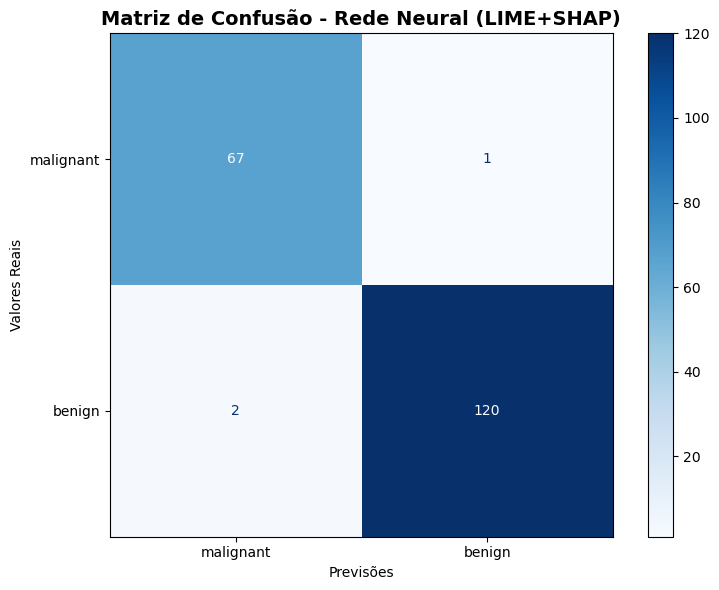


--- Relatório de Classificação ---
              precision    recall  f1-score   support

   malignant       0.97      0.99      0.98        68
      benign       0.99      0.98      0.99       122

    accuracy                           0.98       190
   macro avg       0.98      0.98      0.98       190
weighted avg       0.98      0.98      0.98       190



In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. Fazer as previsões com o modelo treinado
predictions = mlp_model.predict(X_test_scaled)

# 2. Criar a matriz de confusão
cm = confusion_matrix(y_test, predictions)

# 3. Configurar a visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=raw_data.target_names)

# 4. Desenhar o gráfico
disp.plot(cmap='Blues', ax=ax)
ax.grid(False)
plt.title("Matriz de Confusão - Rede Neural (LIME+SHAP)", fontsize=14, fontweight='bold')
plt.xlabel("Previsões")
plt.ylabel("Valores Reais")
plt.tight_layout()
plt.savefig("confusion_matrix_mlp.png", dpi=300, bbox_inches='tight')
plt.show()

# 5. Exibir relatório de classificação
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, predictions, target_names=raw_data.target_names))